# k-Fold and Stratified k-Fold Cross-Validation

## Overview

k-fold CV partitions the data into k equal-sized folds. Each fold serves as the validation set exactly once while the remaining k−1 folds form the training set. The k performance estimates are averaged for a single CV estimate.

**Key choices:**

| Choice | Trade-off | Typical recommendation |
|---|---|---|
| **k = 5** | Lower variance of estimate; more bias; faster | Default for most problems |
| **k = 10** | Less bias; more variance; slower | When compute allows |
| **k = n (LOOCV)** | Minimal bias; high variance; very slow | See `loocv.ipynb` |
| **Stratified** | Preserves class balance in each fold | Always use for classification |
| **Repeated k-fold** | Averages over multiple random partitions; reduces variance | When k-fold variance is high |
| **Group k-fold** | Groups stay intact; prevents leakage | When observations share a group |

**CV error vs. test error:** CV error estimates generalisation performance on unseen data from the same distribution. It is used for model comparison and hyperparameter selection — not as the final reported performance (that requires a held-out test set).

---

## Setup

In [1]:
library(tidyverse)
library(ggplot2)
library(rsample)     # vfold_cv(), group_vfold_cv()
library(recipes)
library(parsnip)     # tidymodels model specs
library(workflows)   # bundle recipe + model
library(tune)        # fit_resamples()
library(yardstick)
library(patchwork)

set.seed(42)

n <- 500
cv_data <- tibble(
  catchment  = sample(1:25, n, replace=TRUE),
  nitrate    = rnorm(n, 3, 1.2),
  water_qual = rnorm(n, 6, 1.5),
  distance   = rexp(n, 0.4),
  elevation  = rnorm(n, 200, 80),
  present    = factor(rbinom(n, 1,
                       plogis(-1 + 0.6*water_qual - 0.7*nitrate)),
                      levels=c(0,1), labels=c("absent","present"))
)

# Hold out a proper test set — CV is for model selection only
init_split <- rsample::initial_split(cv_data, prop=0.80, strata=present)
train_data <- rsample::training(init_split)
test_data  <- rsample::testing(init_split)

Warning message:
"package 'tidyverse' was built under R version 4.4.3"
Warning message:
"package 'ggplot2' was built under R version 4.4.3"
Warning message:
"package 'purrr' was built under R version 4.4.3"
Warning message:
"package 'dplyr' was built under R version 4.4.3"
Warning message:
"package 'stringr' was built under R version 4.4.3"
── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.0     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.6.0
✔ ggplot2   4.0.2     ✔ tibble    3.2.1
✔ lubridate 1.9.3     ✔ tidyr     1.3.1
✔ purrr     1.2.1     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Warning message:
"package 'rsample' was built under R version 4.4.3"
Warning message:
"package 'recipes' was built under R version 4.

---

## Standard k-Fold CV with tidymodels

In [2]:
# ── Resampling scheme ─────────────────────────────────────────────────────────
kfold_10    <- rsample::vfold_cv(train_data, v=10, strata=present)
kfold_5     <- rsample::vfold_cv(train_data, v=5,  strata=present)
repeated_kf <- rsample::vfold_cv(train_data, v=10, repeats=3, strata=present)

cat(sprintf("10-fold:         %d resamples\n", nrow(kfold_10)))
cat(sprintf("5-fold:          %d resamples\n", nrow(kfold_5)))
cat(sprintf("10-fold ×3 rep:  %d resamples\n", nrow(repeated_kf)))

# ── Define a model + recipe workflow ─────────────────────────────────────────
rec <- recipe(present ~ nitrate + water_qual + distance + elevation,
              data=train_data) %>%
  step_normalize(all_numeric_predictors())

rf_spec <- parsnip::rand_forest(
  mode  = "classification",
  trees = 500,
  mtry  = 3
) %>%
  set_engine("ranger", importance="permutation", seed=42)

wf <- workflows::workflow() %>%
  add_recipe(rec) %>%
  add_model(rf_spec)

# ── Fit across resamples ──────────────────────────────────────────────────────
metrics_set <- yardstick::metric_set(roc_auc, accuracy, f_meas)

cv_results <- tune::fit_resamples(
  wf,
  resamples = kfold_10,
  metrics   = metrics_set,
  control   = tune::control_resamples(save_pred=TRUE)
)

# Summary: mean ± SE across folds
tune::collect_metrics(cv_results) %>%
  select(.metric, mean, std_err, n) %>%
  mutate(across(c(mean, std_err), ~round(.x, 4))) %>%
  print()

10-fold:         10 resamples
5-fold:          5 resamples
10-fold ×3 rep:  30 resamples
# A tibble: 3 × 4
  .metric   mean std_err     n
  <chr>    <dbl>   <dbl> <int>
1 accuracy 0.697  0.0213    10
2 f_meas   0.553  0.0428    10
3 roc_auc  0.690  0.0243    10


---

## Comparing k Values

Warning message:
"The `fatten` argument of `geom_pointrange()` is deprecated as of ggplot2 4.0.0.
ℹ Please use the `size` aesthetic instead."
Warning message:
"Removed 3 rows containing missing values or values outside the scale range
(`geom_pointrange()`)."


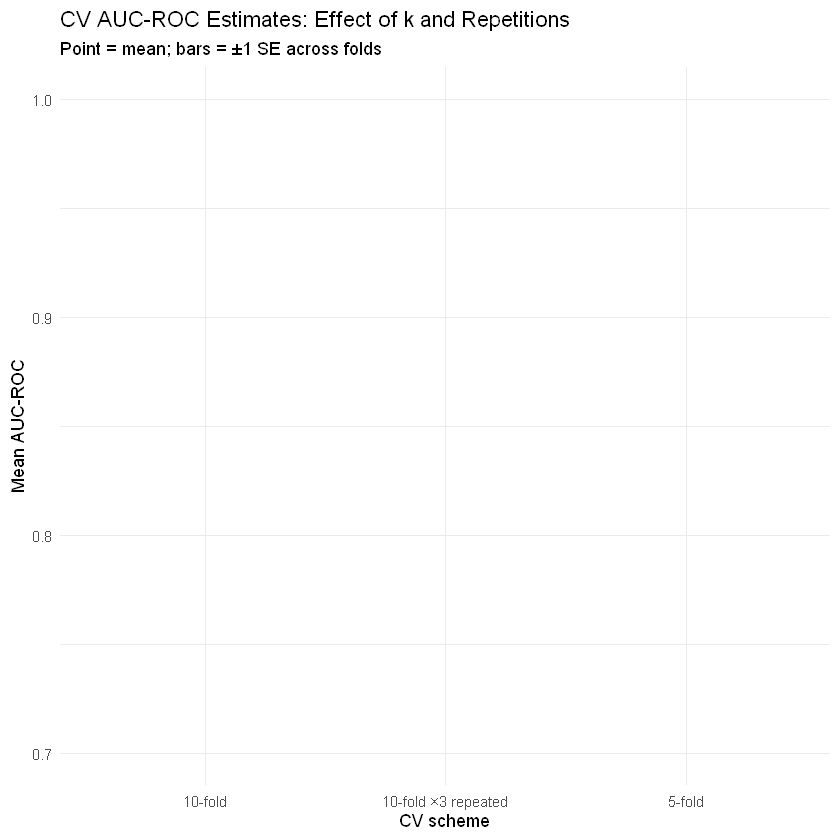

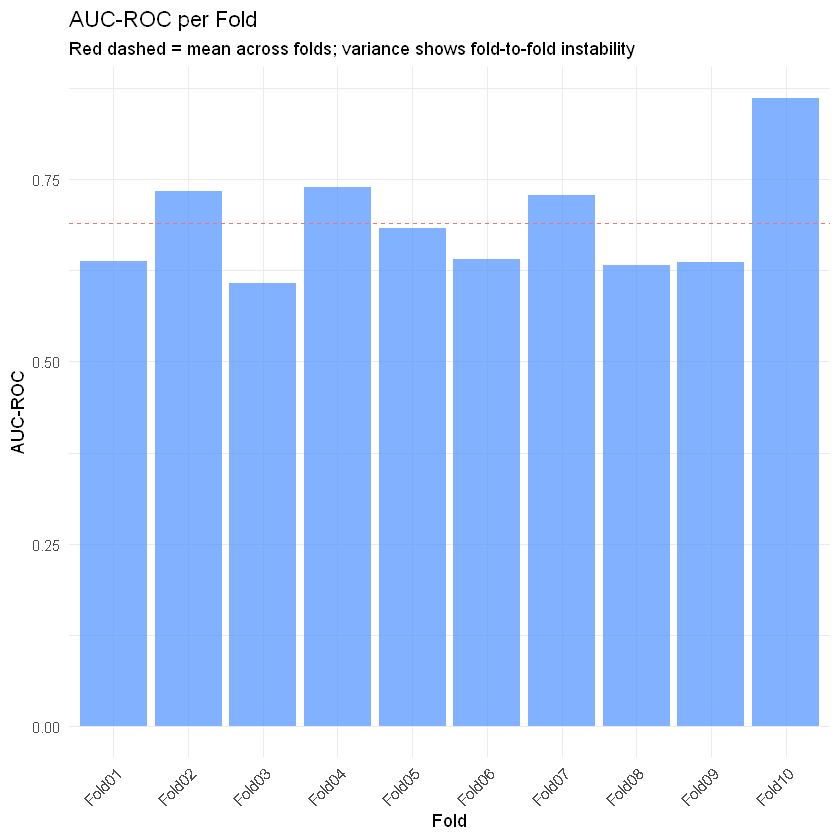

In [3]:
# Compare CV estimates across k=5, 10, and repeated 10-fold
fit_cv <- function(resamples, label) {
  tune::fit_resamples(wf, resamples=resamples,
                      metrics=metric_set(roc_auc)) %>%
    tune::collect_metrics() %>%
    mutate(scheme=label)
}

cv_comparison <- bind_rows(
  fit_cv(kfold_5,     "5-fold"),
  fit_cv(kfold_10,    "10-fold"),
  fit_cv(repeated_kf, "10-fold ×3 repeated")
)

ggplot(cv_comparison, aes(x=scheme, y=mean,
                           ymin=mean-std_err, ymax=mean+std_err)) +
  geom_pointrange(color="#4a8fff", linewidth=0.8, fatten=3) +
  scale_y_continuous(limits=c(0.7, 1.0)) +
  labs(title="CV AUC-ROC Estimates: Effect of k and Repetitions",
       subtitle="Point = mean; bars = ±1 SE across folds",
       x="CV scheme", y="Mean AUC-ROC") +
  theme_minimal()

# Per-fold distribution — shows variance across folds
tune::collect_metrics(cv_results, summarize=FALSE) %>%
  filter(.metric=="roc_auc") %>%
  ggplot(aes(x=id, y=.estimate)) +
  geom_col(fill="#4a8fff", alpha=0.7) +
  geom_hline(yintercept=mean(
    tune::collect_metrics(cv_results, summarize=FALSE) %>%
    filter(.metric=="roc_auc") %>% pull(.estimate)
  ), linetype="dashed", color="#ff6b6b") +
  labs(title="AUC-ROC per Fold",
       subtitle="Red dashed = mean across folds; variance shows fold-to-fold instability",
       x="Fold", y="AUC-ROC") +
  theme_minimal() + theme(axis.text.x=element_text(angle=45, hjust=1))

---

## Group k-Fold CV

In [4]:
# Group CV: all observations from the same catchment stay in the same fold
group_cv <- rsample::group_vfold_cv(
  train_data,
  group = "catchment",
  v     = 5    # 5 groups-of-catchments as validation each time
)

group_results <- tune::fit_resamples(
  wf,
  resamples = group_cv,
  metrics   = metric_set(roc_auc)
)

standard_auc <- tune::collect_metrics(cv_results) %>%
  filter(.metric=="roc_auc") %>% pull(mean)

group_auc <- tune::collect_metrics(group_results) %>%
  filter(.metric=="roc_auc") %>% pull(mean)

cat(sprintf("Standard 10-fold CV AUC: %.4f\n", standard_auc))
cat(sprintf("Group-aware  5-fold CV AUC: %.4f\n", group_auc))
# Group CV is typically lower — it is a more honest estimate because the model
# cannot exploit catchment-level effects from training to predict test observations
# from the same catchments

Standard 10-fold CV AUC: 0.6897
Group-aware  5-fold CV AUC: 0.6612


---

## Common Pitfalls

**1. Fitting preprocessing inside the CV loop manually instead of using a workflow**  
If you normalise features before creating folds, the scaling statistics are computed on all data including the validation fold — preprocessing leakage. The `workflow()` + `fit_resamples()` pipeline fits the recipe inside each fold on training data only, and applies it to the validation fold correctly.

**2. Reporting CV performance as the final model performance**  
CV estimates are for model selection. The final reported performance must come from the held-out test set, evaluated exactly once after all model decisions are made. Reporting CV mean AUC as the result is optimistic because it was used to make decisions.

**3. Not using stratified folds for imbalanced classification**  
Without `strata=`, a fold may contain very few minority class observations by chance, making its AUC estimate unreliable and unrepresentative. Always use `strata=present` for binary classification with any imbalance.

**4. Ignoring the SE across folds**  
A CV mean AUC of 0.82 from k=5 folds could have SE of 0.04 — models with AUC estimates of 0.80 and 0.83 are indistinguishable. Always report the SE and avoid selecting models based on differences smaller than 1–2 SE.

**5. Using random k-fold when group structure exists**  
If sites within catchments, patients with repeated measures, or temporally structured observations are split randomly across folds, the CV estimate is optimistic. Use `group_vfold_cv()` or `rolling_origin()` as appropriate.

---
*r_methods_library · Samantha McGarrigle · [github.com/samantha-mcgarrigle](https://github.com/samantha-mcgarrigle)*